# 05 — Results Analysis

Corporate carbon damages (absolute, relative, sector breakdown)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['cmr10', 'Computer Modern Roman', 'DejaVu Serif'],
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'mathtext.fontset':  'cm',
    'axes.unicode_minus': False,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'figure.dpi':        150,
    'savefig.dpi':       300,
})

C_BLUE   = '#2166ac'
C_ORANGE = '#f4a020'
C_GREEN  = '#2ca02c'
C_RED    = '#d6604d'


In [2]:
df_final = pd.read_parquet(
    "../data/processed/df_lm_avg_baseline_wti_gind.parquet", engine="pyarrow"
)

df_final_gam = pd.read_parquet(
    "../data/processed/df_gam_avg_baseline_wti_gind.parquet", engine="pyarrow"
)

for df_ in [df_final]:
    df_["sc1"] = df_["sc1_disclosed"].fillna(df_["sc1_estimated"])
    df_["sc1_disclosed_filled"] = df_["sc1_disclosed_complete"]

## Corporate carbon damages

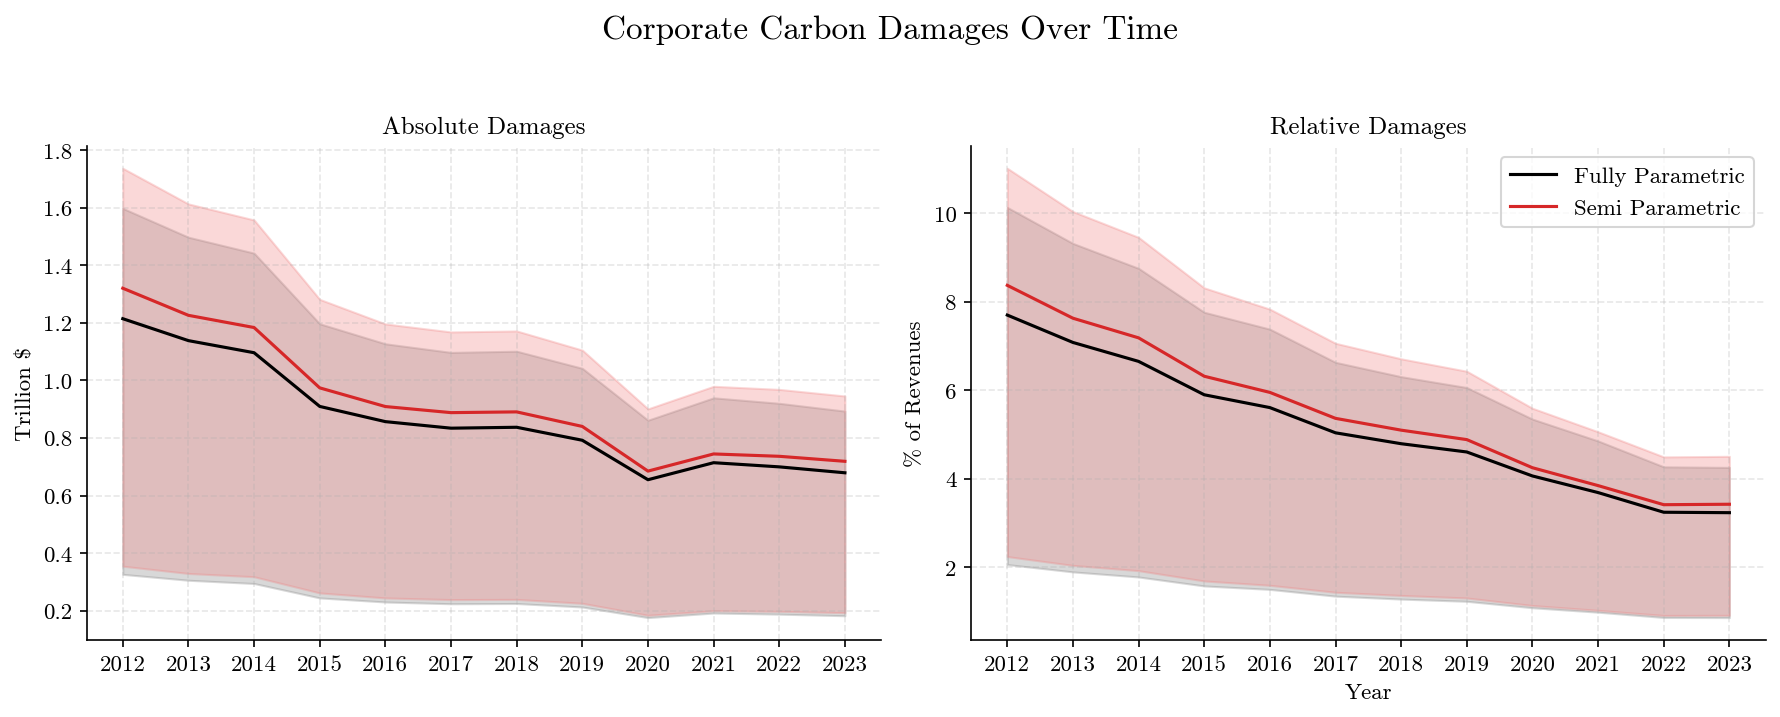

In [3]:
# Cost scenarios ($/tCO2)
COSTS = {"low": 51, "mid": 190, "high": 250}
SCALE = 1e12  # express in trillions

# Aggregate by year
yearly_emis_lm = df_final.groupby("year")["sc1_adj"].sum()
yearly_emis_gam = df_final_gam.groupby("year")["sc1_adj"].sum()
yearly_revt = df_final.groupby("year")["revt"].sum()
years = yearly_emis_lm.index

# Absolute damages (Trillion $)
abs_lm = np.stack([yearly_emis_lm.values * c / SCALE for c in COSTS.values()], axis=1)
abs_gam = np.stack([yearly_emis_gam.values * c / SCALE for c in COSTS.values()], axis=1)

# Relative damages (% of revenues)
rel_lm = {k: (abs_lm[:, i] * 1e6 / yearly_revt.values) * 100 for i, k in enumerate(COSTS)}
rel_gam = {k: (abs_gam[:, i] * 1e6 / yearly_revt.values) * 100 for i, k in enumerate(COSTS)}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].plot(years, abs_lm[:, 1], label="Fully Parametric", color="black")
axes[0].fill_between(years, abs_lm[:, 0], abs_lm[:, 2], color="gray", alpha=0.3)
axes[0].plot(years, abs_gam[:, 1], label="Semi Parametric", color="tab:red")
axes[0].fill_between(years, abs_gam[:, 0], abs_gam[:, 2], color="lightcoral", alpha=0.3)
axes[0].set_ylabel("Trillion $")
axes[0].set_title("Absolute Damages")
axes[0].grid(alpha=0.3, linestyle="--")

axes[1].plot(years, rel_lm["mid"], label="Fully Parametric", color="black")
axes[1].fill_between(years, rel_lm["low"], rel_lm["high"], color="gray", alpha=0.3)
axes[1].plot(years, rel_gam["mid"], label="Semi Parametric", color="tab:red")
axes[1].fill_between(years, rel_gam["low"], rel_gam["high"], color="lightcoral", alpha=0.3)
axes[1].set_ylabel("% of Revenues")
axes[1].set_xlabel("Year")
axes[1].set_title("Relative Damages")
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].legend()

plt.suptitle("Corporate Carbon Damages Over Time", fontsize=16)
axes[1].set_xticks(years)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [4]:
idx_2023 = np.where(years == 2019)[0][0]

print("=== Absolute Carbon Damages (Trillion $) in 2023 ===")
for label, arr in [("Fully Parametric", abs_lm), ("Semi Parametric", abs_gam)]:
    print(f"{label}:")
    for i, (k, c) in enumerate(COSTS.items()):
        print(f"  {k:4s} (${c}/tCO2): {arr[idx_2023, i]:.4f} T$")

print(f"\n=== Relative Carbon Damages (% of Revenues) in 2023 ===")
for label, rel in [("Fully Parametric", rel_lm), ("Semi Parametric", rel_gam)]:
    print(f"{label}:")
    for k in COSTS:
        print(f"  {k:4s}: {rel[k][idx_2023]:.2f}%")

=== Absolute Carbon Damages (Trillion $) in 2023 ===
Fully Parametric:
  low  ($51/tCO2): 0.2126 T$
  mid  ($190/tCO2): 0.7921 T$
  high ($250/tCO2): 1.0422 T$
Semi Parametric:
  low  ($51/tCO2): 0.2255 T$
  mid  ($190/tCO2): 0.8401 T$
  high ($250/tCO2): 1.1054 T$

=== Relative Carbon Damages (% of Revenues) in 2023 ===
Fully Parametric:
  low : 1.24%
  mid : 4.61%
  high: 6.06%
Semi Parametric:
  low : 1.31%
  mid : 4.89%
  high: 6.43%


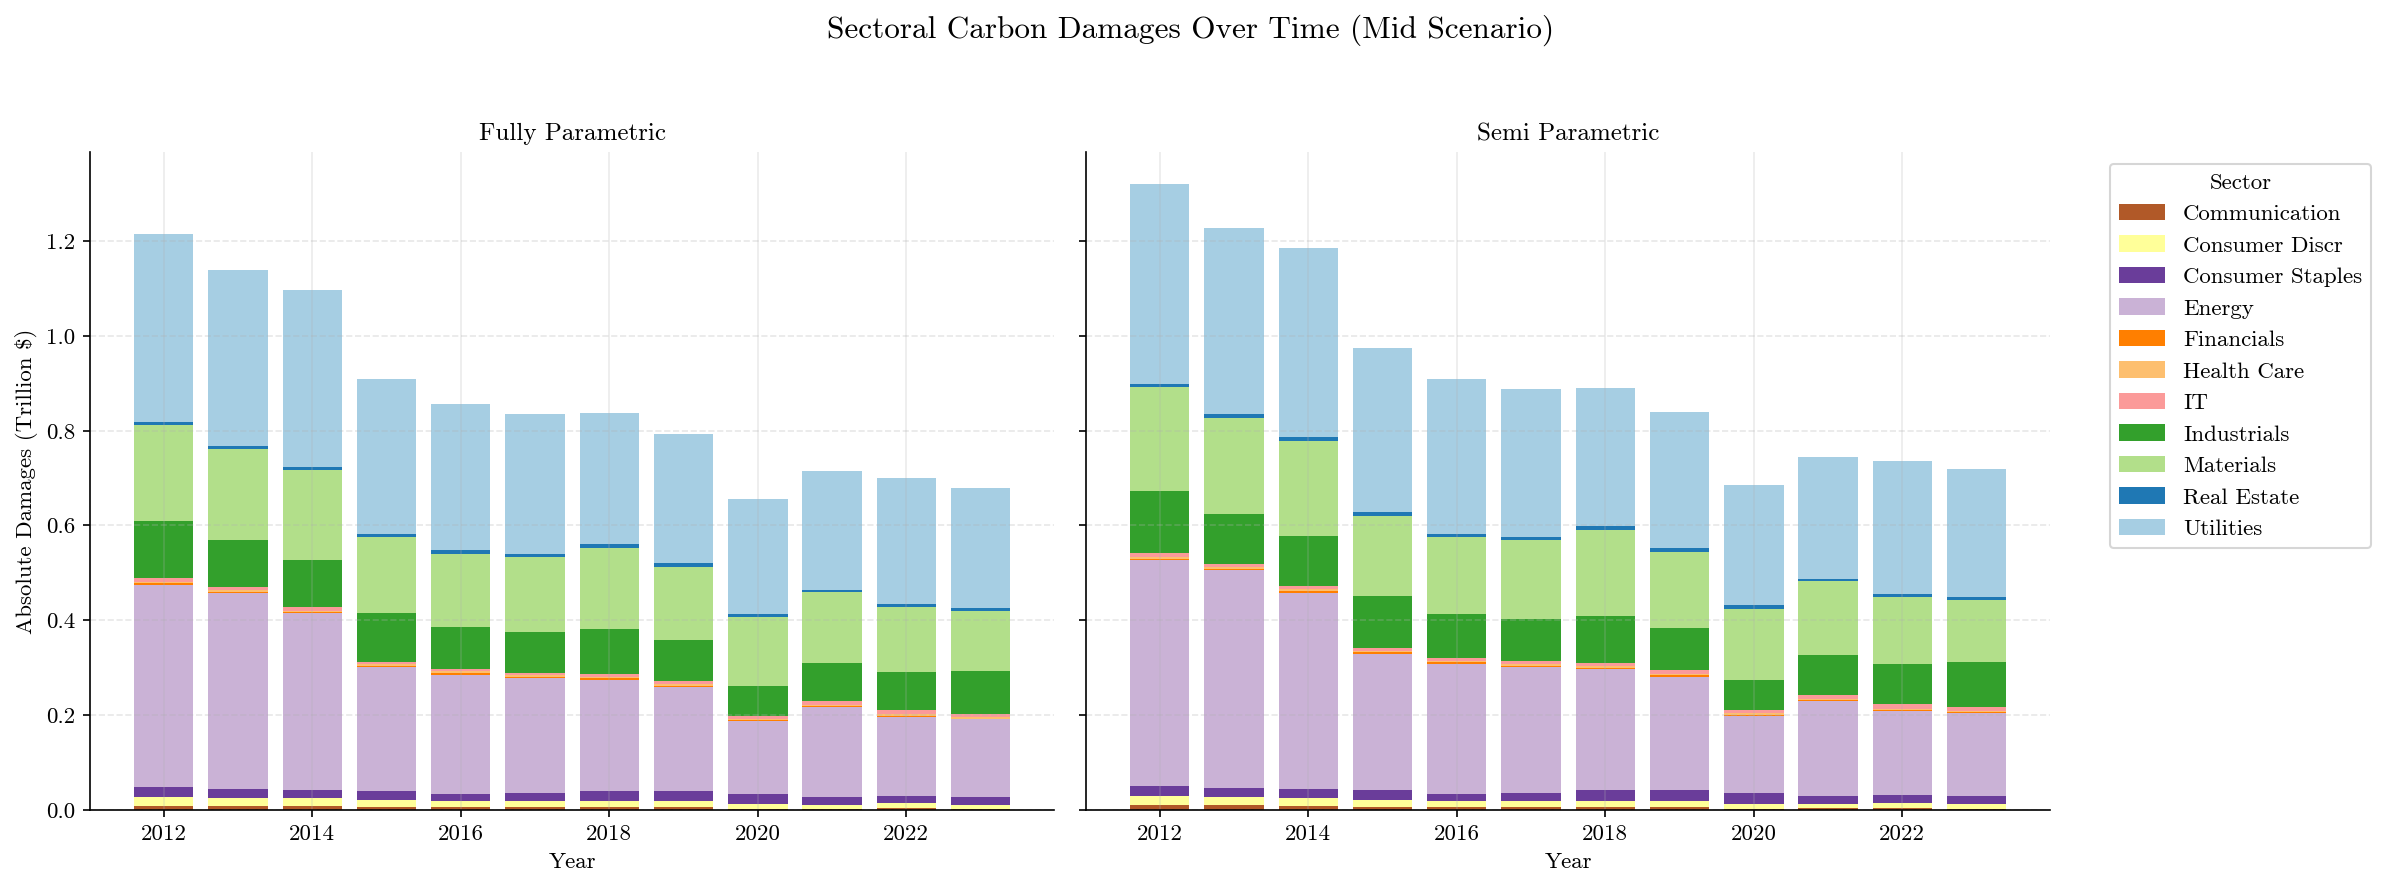

In [5]:
# Sector breakdown (mid scenario only)
all_years = sorted(df_final["year"].unique())
sectors = sorted(df_final["gsector"].unique())

data_lm = np.zeros((len(all_years), len(sectors)))
data_gam = np.zeros((len(all_years), len(sectors)))

for j, sector in enumerate(sectors):
    emis_lm = df_final[df_final["gsector"] == sector].groupby("year")["sc1_adj"].sum()
    emis_gam = df_final_gam[df_final_gam["gsector"] == sector].groupby("year")["sc1_adj"].sum()
    for i, yr in enumerate(all_years):
        if yr in emis_lm.index:
            data_lm[i, j] = emis_lm[yr] * COSTS["mid"] / SCALE
        if yr in emis_gam.index:
            data_gam[i, j] = emis_gam[yr] * COSTS["mid"] / SCALE

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
colors = plt.get_cmap("Paired")(np.linspace(0, 1, len(sectors)))

for ax, data, title in zip(axes, [data_lm, data_gam], ["Fully Parametric", "Semi Parametric"]):
    bottoms = np.zeros(len(all_years))
    for j, sector in enumerate(sectors):
        c = colors[len(sectors) - j - 1]
        ax.bar(all_years, data[:, j], bottom=bottoms, label=sector, color=c)
        bottoms += data[:, j]
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Absolute Damages (Trillion $)")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Sector")
plt.suptitle("Sectoral Carbon Damages Over Time (Mid Scenario)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()